# 04 - Multilevel Models

The OLS in notebook 03 treats all 3,100 counties as independent observations, ignoring that counties are nested within states. A multilevel model accounts for this clustering and lets us ask: how much of the swing variation is between states vs. within states? And does the education-swing relationship vary across states?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats

plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

df = pd.read_csv("../data/processed/county_swing_dataset.csv",
                 dtype={"FIPS": str, "state_fips": str})
df_main = df[~df["is_alaska"]].copy()
print(f"Counties in analysis: {len(df_main)}")

Counties in analysis: 3111


## Data preparation

In [2]:
# Grand-mean center the key predictors
df_main["college_c"] = df_main["pct_college"] - df_main["pct_college"].mean()
df_main["unemp_change_c"] = df_main["unemp_rate_change"] - df_main["unemp_rate_change"].mean()

# Drop rows missing any model variable, cast urban_rural_code
model_vars = ["swing", "state_fips", "college_c", "pct_hispanic", "log_pop_density",
              "rep_share_2020", "pct_black", "log_median_income", "urban_rural_code",
              "unemp_change_c"]
mlm_df = df_main.dropna(subset=model_vars).copy()
mlm_df["urban_rural_code"] = mlm_df["urban_rural_code"].astype(int)

print(f"Observations for modeling: {len(mlm_df)}")
print(f"States: {mlm_df.state_fips.nunique()}")
print(f"College pct mean: {df_main.pct_college.mean()*100:.1f}% (centering target)")
print(f"Unemp change mean: {df_main.unemp_rate_change.mean():.2f} pp (centering target)")

Observations for modeling: 3101
States: 49
College pct mean: 24.1% (centering target)
Unemp change mean: -3.42 pp (centering target)


## Step 1: Null model (ICC)

How much of the county-level swing variance sits at the state level?

In [3]:
m0 = smf.mixedlm("swing ~ 1", data=mlm_df, groups=mlm_df["state_fips"])
m0_fit = m0.fit(method="powell", reml=False)
print(m0_fit.summary())

# ICC = state variance / (state variance + residual variance)
var_state = m0_fit.cov_re.iloc[0, 0]
var_resid = m0_fit.scale
icc = var_state / (var_state + var_resid)

print(f"\nState-level variance (tau_00): {var_state:.6f}")
print(f"Residual variance (sigma^2):   {var_resid:.6f}")
print(f"ICC = {icc:.4f}")
print(f"\n{icc*100:.1f}% of the variance in county-level partisan swing is between states.")

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: swing    
No. Observations: 3101    Method:             ML       
No. Groups:       49      Scale:              0.0002   
Min. group size:  1       Log-Likelihood:     8618.3054
Max. group size:  253     Converged:          Yes      
Mean group size:  63.3                                 
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.018    0.001 12.402 0.000  0.015  0.021
Group Var     0.000    0.001                           


State-level variance (tau_00): 0.000095
Residual variance (sigma^2):   0.000215
ICC = 0.3052

30.5% of the variance in county-level partisan swing is between states.


C:\Users\kaleb\OneDrive\Desktop\Portfolio\us-election-county-swing\venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## Step 2: Random intercepts + county-level predictors

In [4]:
formula = ("swing ~ college_c + pct_hispanic + log_pop_density + "
          "rep_share_2020 + pct_black + log_median_income + "
          "C(urban_rural_code)")

m1 = smf.mixedlm(formula, data=mlm_df, groups=mlm_df["state_fips"])
m1_fit = m1.fit(method="powell", reml=False)
print(m1_fit.summary())

lr_10 = 2 * (m1_fit.llf - m0_fit.llf)
df_diff_10 = len(m1_fit.fe_params) - len(m0_fit.fe_params)
p_10 = stats.chi2.sf(lr_10, df_diff_10)
print(f"\nLR test vs null: chi2={lr_10:.2f}, df={df_diff_10}, p={p_10:.2e}")

               Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     swing    
No. Observations:      3101        Method:                 ML       
No. Groups:            49          Scale:                  0.0001   
Min. group size:       1           Log-Likelihood:         9267.2119
Max. group size:       253         Converged:              Yes      
Mean group size:       63.3                                         
--------------------------------------------------------------------
                         Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                 0.092    0.018   5.122 0.000  0.057  0.127
C(urban_rural_code)[T.2] -0.003    0.002  -1.934 0.053 -0.007  0.000
C(urban_rural_code)[T.3] -0.003    0.002  -1.808 0.071 -0.007  0.000
C(urban_rural_code)[T.4] -0.002    0.002  -1.091 0.275 -0.006  0.002
C(urban_rural_code)[T.5] -0.002    0.002  -1.315 0

C:\Users\kaleb\OneDrive\Desktop\Portfolio\us-election-county-swing\venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## Step 3: Add random slope on education

Does the effect of college education on swing vary across states?

In [5]:
m2 = smf.mixedlm(formula, data=mlm_df,
                 groups=mlm_df["state_fips"],
                 re_formula="~college_c")
m2_fit = m2.fit(method="powell", reml=False)
print(m2_fit.summary())

# LR test: m2 vs m1 (added slope variance + covariance = 2 parameters)
lr_21 = 2 * (m2_fit.llf - m1_fit.llf)
p_21 = stats.chi2.sf(lr_21, 2)
print(f"\nLR test (random slope): chi2={lr_21:.2f}, df=2, p={p_21:.2e}")
if p_21 < 0.05:
    print("The education effect DOES vary significantly across states.")
else:
    print("The education effect does NOT vary significantly across states.")

               Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     swing    
No. Observations:      3101        Method:                 ML       
No. Groups:            49          Scale:                  0.0001   
Min. group size:       1           Log-Likelihood:         9303.4186
Max. group size:       253         Converged:              Yes      
Mean group size:       63.3                                         
--------------------------------------------------------------------
                         Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                 0.087    0.018   4.869 0.000  0.052  0.122
C(urban_rural_code)[T.2] -0.004    0.002  -2.113 0.035 -0.007 -0.000
C(urban_rural_code)[T.3] -0.003    0.002  -1.922 0.055 -0.007  0.000
C(urban_rural_code)[T.4] -0.002    0.002  -1.329 0.184 -0.006  0.001
C(urban_rural_code)[T.5] -0.003    0.002  -1.534 0

C:\Users\kaleb\OneDrive\Desktop\Portfolio\us-election-county-swing\venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## Step 4: Cross-level interaction

Does state-level unemployment change explain why the education effect varies?

In [6]:
formula_interact = ("swing ~ college_c * unemp_change_c + pct_hispanic + "
                    "log_pop_density + rep_share_2020 + pct_black + "
                    "log_median_income + C(urban_rural_code)")

m3 = smf.mixedlm(formula_interact, data=mlm_df,
                 groups=mlm_df["state_fips"],
                 re_formula="~college_c")
m3_fit = m3.fit(method="powell", reml=False)
print(m3_fit.summary())

lr_32 = 2 * (m3_fit.llf - m2_fit.llf)
p_32 = stats.chi2.sf(lr_32, 2)
interact_p = m3_fit.pvalues.get("college_c:unemp_change_c", float("nan"))
interact_coef = m3_fit.fe_params.get("college_c:unemp_change_c", float("nan"))
print(f"\nInteraction coefficient: {interact_coef:.6f}")
print(f"Interaction p-value: {interact_p:.4f}")
print(f"LR test vs m2: chi2={lr_32:.2f}, p={p_32:.4f}")

               Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     swing    
No. Observations:      3101        Method:                 ML       
No. Groups:            49          Scale:                  0.0001   
Min. group size:       1           Log-Likelihood:         9303.9778
Max. group size:       253         Converged:              Yes      
Mean group size:       63.3                                         
--------------------------------------------------------------------
                         Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                 0.088    0.018   4.895 0.000  0.052  0.123
C(urban_rural_code)[T.2] -0.004    0.002  -2.098 0.036 -0.007 -0.000
C(urban_rural_code)[T.3] -0.003    0.002  -1.900 0.057 -0.007  0.000
C(urban_rural_code)[T.4] -0.002    0.002  -1.311 0.190 -0.006  0.001
C(urban_rural_code)[T.5] -0.003    0.002  -1.517 0

C:\Users\kaleb\OneDrive\Desktop\Portfolio\us-election-county-swing\venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


The cross-level interaction is not significant. The education-swing relationship varies across states (Step 3 confirmed this), but state-level unemployment change does not explain that variation. What drives the state-level differences remains an open question.

## Refit best model with REML for final reporting

ML estimation is needed for likelihood ratio tests, but REML gives less biased variance component estimates. Refit m2 with REML for the numbers we report.

In [7]:
m2_reml = smf.mixedlm(formula, data=mlm_df,
                      groups=mlm_df["state_fips"],
                      re_formula="~college_c")
m2_reml_fit = m2_reml.fit(method="powell")  # default is REML
print(m2_reml_fit.summary())

               Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     swing    
No. Observations:      3101        Method:                 REML     
No. Groups:            49          Scale:                  0.0001   
Min. group size:       1           Log-Likelihood:         9234.0147
Max. group size:       253         Converged:              Yes      
Mean group size:       63.3                                         
--------------------------------------------------------------------
                         Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                 0.087    0.018   4.852 0.000  0.052  0.122
C(urban_rural_code)[T.2] -0.004    0.002  -2.122 0.034 -0.007 -0.000
C(urban_rural_code)[T.3] -0.003    0.002  -1.929 0.054 -0.007  0.000
C(urban_rural_code)[T.4] -0.002    0.002  -1.339 0.181 -0.006  0.001
C(urban_rural_code)[T.5] -0.003    0.002  -1.544 0

C:\Users\kaleb\OneDrive\Desktop\Portfolio\us-election-county-swing\venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## Model comparison table

In [8]:
rows = []
for name, fit in [("m0_null", m0_fit), ("m1_random_intercept", m1_fit),
                   ("m2_random_slope", m2_fit), ("m3_interaction", m3_fit)]:
    rows.append({
        "model": name,
        "log_likelihood": round(fit.llf, 2),
        "aic": round(fit.aic, 2),
        "bic": round(fit.bic, 2),
        "n_fixed_effects": len(fit.fe_params),
    })

comp_df = pd.DataFrame(rows)
comp_df.to_csv("../data/processed/model_comparison.csv", index=False)
print(comp_df.to_string(index=False))

              model  log_likelihood       aic       bic  n_fixed_effects
            m0_null         8618.31 -17230.61 -17212.49                1
m1_random_intercept         9267.21 -18506.42 -18421.87               12
    m2_random_slope         9303.42 -18574.84 -18478.21               12
     m3_interaction         9303.98 -18571.96 -18463.24               14


## Extract and save random effects (BLUPs)

All saved outputs come from the REML fit (m2_reml_fit).

In [9]:
sample_re = list(m2_reml_fit.random_effects.values())[0]
print(f"Random effects keys: {list(sample_re.index)}")

re_rows = []
for state, effects in m2_reml_fit.random_effects.items():
    re_rows.append({
        "state_fips": state,
        "intercept_re": effects.iloc[0],
        "slope_college_re": effects.iloc[1] if len(effects) > 1 else 0.0,
    })
state_re = pd.DataFrame(re_rows)

try:
    from us import states as us_states
    fips_to_name = {s.fips: s.name for s in us_states.STATES_AND_TERRITORIES}
    fips_to_name["11"] = "District of Columbia"
    fips_to_abbr = {s.fips: s.abbr for s in us_states.STATES_AND_TERRITORIES}
    fips_to_abbr["11"] = "DC"
    state_re["state_name"] = state_re["state_fips"].map(fips_to_name)
    state_re["state_abbr"] = state_re["state_fips"].map(fips_to_abbr)
except ImportError:
    state_re["state_name"] = state_re["state_fips"]
    state_re["state_abbr"] = state_re["state_fips"]

state_re["state_name"] = state_re["state_name"].fillna(state_re["state_fips"])
state_re["state_abbr"] = state_re["state_abbr"].fillna(state_re["state_fips"])

state_re.to_csv("../data/processed/state_random_effects.csv", index=False)
print(f"Saved {len(state_re)} state random effects")
print(state_re.sort_values("intercept_re")[["state_name", "intercept_re", "slope_college_re"]].to_string())

Random effects keys: ['Group', 'college_c']
Saved 49 state random effects
              state_name  intercept_re  slope_college_re
45            Washington     -0.017443         -0.032826
29            New Mexico     -0.015112         -0.014511
35                Oregon     -0.013246         -0.036001
4               Colorado     -0.012227         -0.006286
42                  Utah     -0.012156          0.008933
34              Oklahoma     -0.008389         -0.014173
26                Nevada     -0.007574          0.006247
47             Wisconsin     -0.006526         -0.008901
36          Pennsylvania     -0.005916          0.015171
20              Michigan     -0.005435         -0.010799
14                Kansas     -0.005268          0.005779
5               Delaware     -0.005118         -0.005962
31        North Carolina     -0.004618         -0.038412
17                 Maine     -0.004241         -0.027918
12               Indiana     -0.004019         -0.019394
11            

## Save fixed effects from REML fit

In [10]:
fe_names = m2_reml_fit.fe_params.index
fe = pd.DataFrame({
    "term": fe_names,
    "estimate": m2_reml_fit.fe_params.values,
    "std_err": m2_reml_fit.bse[fe_names].values,
    "z": m2_reml_fit.tvalues[fe_names].values,
    "p_value": m2_reml_fit.pvalues[fe_names].values,
})
fe.to_csv("../data/processed/fixed_effects.csv", index=False)
print(fe.to_string(index=False))

                    term  estimate  std_err          z      p_value
               Intercept  0.086886 0.017907   4.852070 1.221796e-06
C(urban_rural_code)[T.2] -0.003691 0.001740  -2.121553 3.387527e-02
C(urban_rural_code)[T.3] -0.003412 0.001769  -1.928885 5.374511e-02
C(urban_rural_code)[T.4] -0.002426 0.001812  -1.338757 1.806496e-01
C(urban_rural_code)[T.5] -0.002814 0.001823  -1.543502 1.227090e-01
C(urban_rural_code)[T.6] -0.002010 0.001909  -1.052638 2.925069e-01
               college_c -0.060082 0.005945 -10.106854 5.151182e-24
            pct_hispanic  0.046114 0.002576  17.901765 1.142434e-71
         log_pop_density -0.000262 0.000264  -0.991298 3.215403e-01
          rep_share_2020 -0.054528 0.003106 -17.554559 5.489167e-69
               pct_black -0.013824 0.003273  -4.224231 2.397582e-05
       log_median_income -0.003045 0.001648  -1.847654 6.465237e-02


## Save interaction predictions

In [11]:
college_range = np.linspace(mlm_df["college_c"].min(), mlm_df["college_c"].max(), 100)
unemp_sd = mlm_df["unemp_change_c"].std()
unemp_levels = {"Mean": 0, "+1 SD": unemp_sd, "-1 SD": -unemp_sd}

b = m3_fit.fe_params
interact_key = "college_c:unemp_change_c"

pred_rows = []
for label, unemp_val in unemp_levels.items():
    pred_swing = (b["Intercept"]
                  + (b["college_c"] + b.get(interact_key, 0) * unemp_val) * college_range
                  + b.get("unemp_change_c", 0) * unemp_val)
    for c, s in zip(college_range, pred_swing):
        pred_rows.append({
            "college_c": c,
            "college_pct": (c + df_main["pct_college"].mean()) * 100,
            "unemp_level": label,
            "predicted_swing": s,
        })

pred_df = pd.DataFrame(pred_rows)
pred_df.to_csv("../data/processed/interaction_predictions.csv", index=False)
print(f"Saved {len(pred_df)} prediction rows")

Saved 300 prediction rows


## Figure 1: Caterpillar plot of state random intercepts

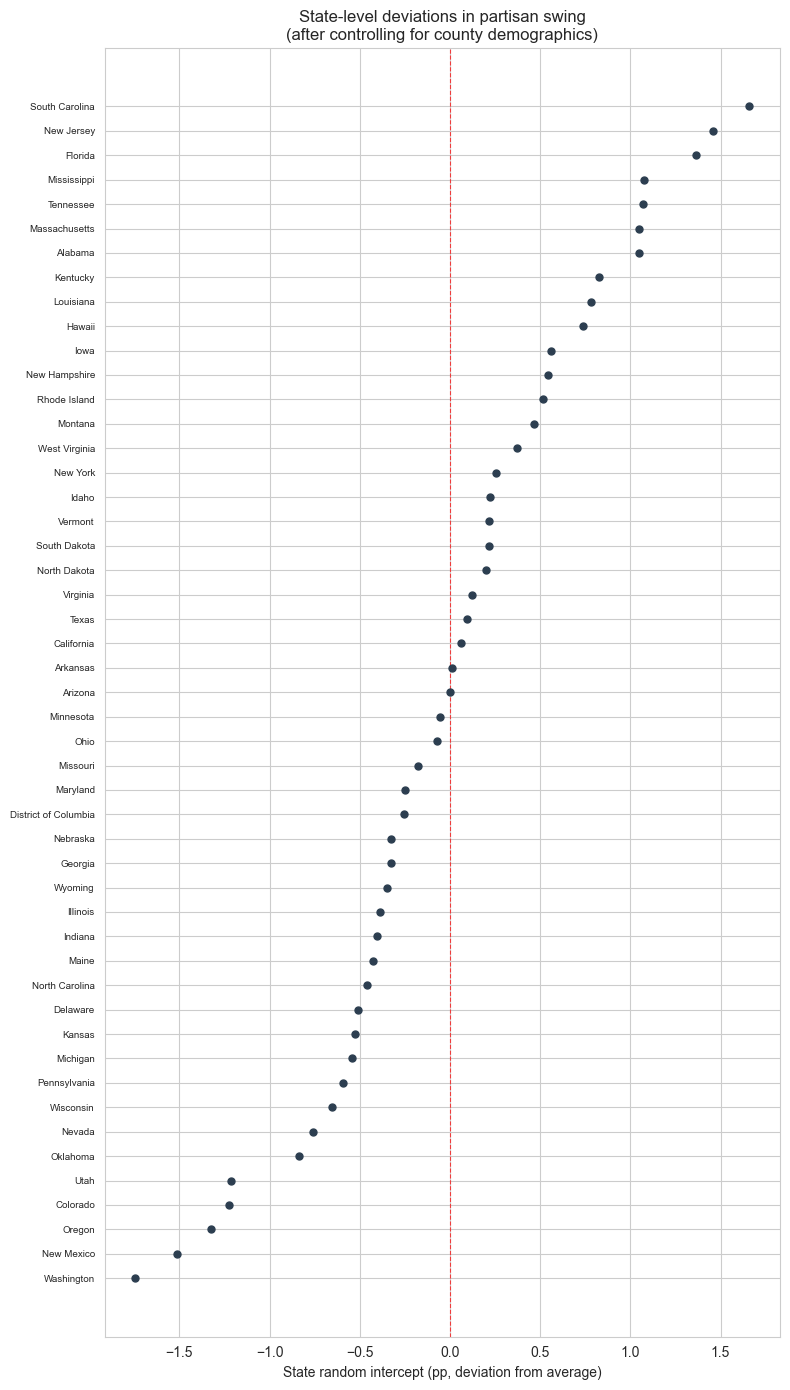

In [12]:
state_sorted = state_re.sort_values("intercept_re")

fig, ax = plt.subplots(figsize=(8, 14))
y_pos = range(len(state_sorted))
ax.scatter(state_sorted["intercept_re"] * 100, y_pos, s=25, color="#2c3e50", zorder=3)
ax.axvline(0, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(state_sorted["state_name"], fontsize=7)
ax.set_xlabel("State random intercept (pp, deviation from average)")
ax.set_title("State-level deviations in partisan swing\n(after controlling for county demographics)")
plt.tight_layout()
plt.savefig("../figures/caterpillar_state_intercepts.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 2: Interaction plot

Education effect at different levels of state unemployment change. The near-parallel lines reflect the non-significant interaction.

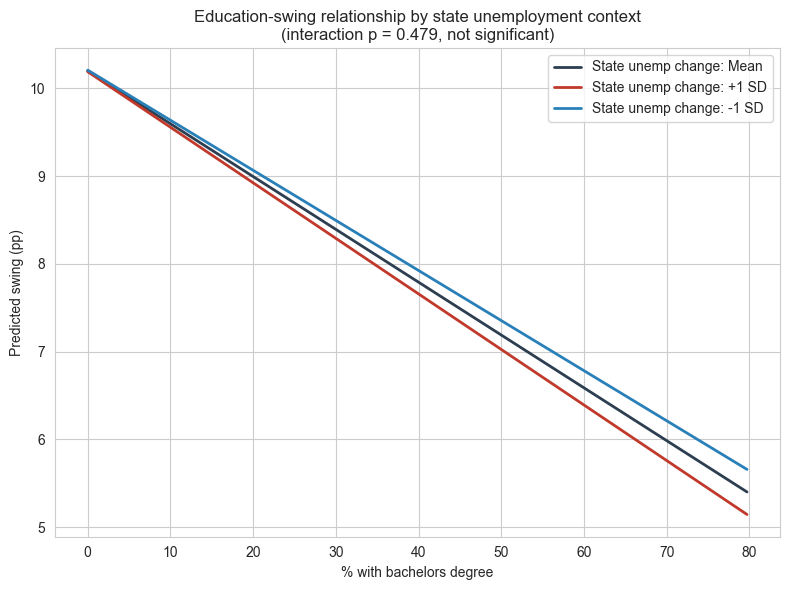

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = {"Mean": "#2c3e50", "+1 SD": "#c0392b", "-1 SD": "#2980b9"}
for label in ["Mean", "+1 SD", "-1 SD"]:
    subset = pred_df[pred_df["unemp_level"] == label]
    ax.plot(subset["college_pct"], subset["predicted_swing"] * 100,
            label=f"State unemp change: {label}", color=colors[label], linewidth=2)

interact_p_val = m3_fit.pvalues.get("college_c:unemp_change_c", float("nan"))
ax.set_xlabel("% with bachelors degree")
ax.set_ylabel("Predicted swing (pp)")
ax.set_title(f"Education-swing relationship by state unemployment context\n(interaction p = {interact_p_val:.3f}, not significant)")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/interaction_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 3: Random slope distribution

How much does the education effect vary across states?

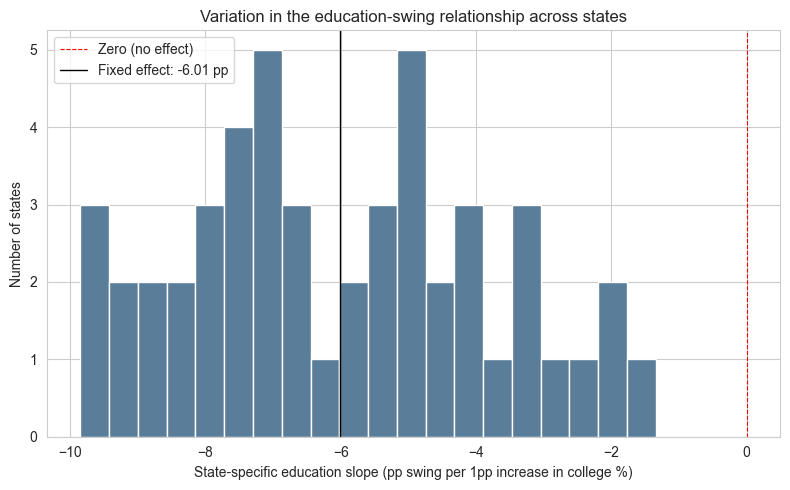

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
total_slopes = (m2_reml_fit.fe_params["college_c"] + state_re["slope_college_re"]) * 100
ax.hist(total_slopes, bins=20, edgecolor="white", color="#5a7d9a")
ax.axvline(0, color="red", linestyle="--", linewidth=0.8, label="Zero (no effect)")
mean_slope = m2_reml_fit.fe_params["college_c"] * 100
ax.axvline(mean_slope, color="black", linestyle="-", linewidth=1,
           label=f"Fixed effect: {mean_slope:.2f} pp")
ax.set_xlabel("State-specific education slope (pp swing per 1pp increase in college %)")
ax.set_ylabel("Number of states")
ax.set_title("Variation in the education-swing relationship across states")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/random_slopes_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 4: Hispanic share with key states highlighted

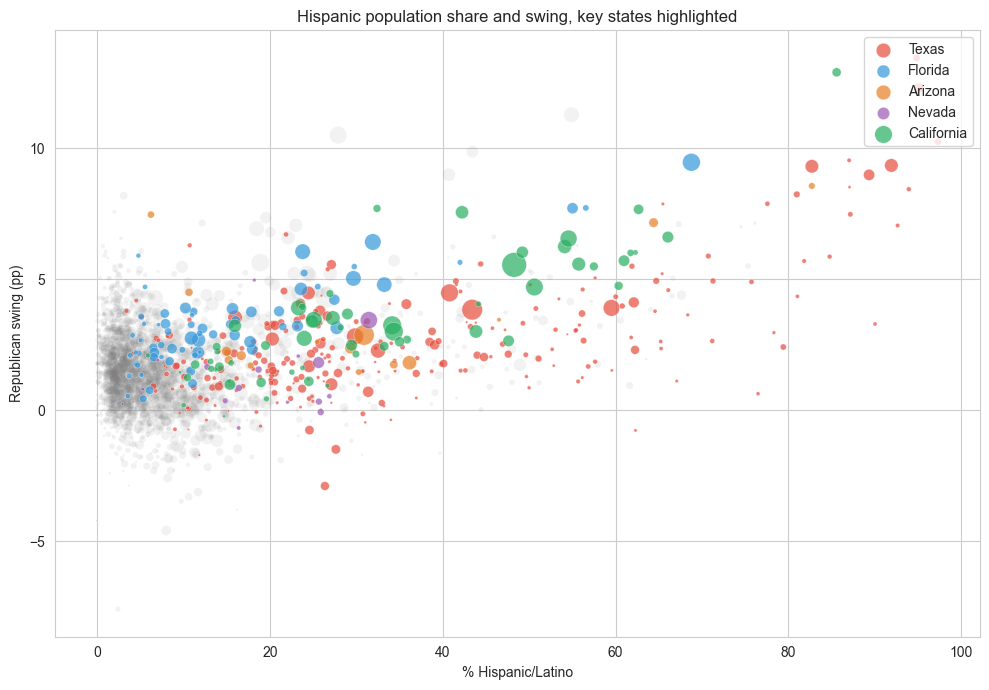

In [15]:
highlight_states = {"48": "Texas", "12": "Florida", "04": "Arizona",
                    "32": "Nevada", "06": "California"}
plot_df = mlm_df.copy()
plot_df["highlight"] = plot_df["state_fips"].map(highlight_states)

fig, ax = plt.subplots(figsize=(10, 7))

bg = plot_df[plot_df["highlight"].isna()]
ax.scatter(bg["pct_hispanic"] * 100, bg["swing"] * 100,
           s=np.sqrt(bg["total_pop"]) / 10, alpha=0.1, color="gray", edgecolors="none")

hl_colors = {"Texas": "#e74c3c", "Florida": "#3498db", "Arizona": "#e67e22",
             "Nevada": "#9b59b6", "California": "#27ae60"}
for fips, name in highlight_states.items():
    sub = plot_df[plot_df["state_fips"] == fips]
    ax.scatter(sub["pct_hispanic"] * 100, sub["swing"] * 100,
               s=np.sqrt(sub["total_pop"]) / 10, alpha=0.7,
               color=hl_colors[name], label=name, edgecolors="white", linewidth=0.3)

ax.set_xlabel("% Hispanic/Latino")
ax.set_ylabel("Republican swing (pp)")
ax.set_title("Hispanic population share and swing, key states highlighted")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../figures/hispanic_highlighted_states.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

The multilevel analysis reveals three key findings:

1. **31% of swing variance is between states** (ICC = 0.31). State-level context matters substantially.
2. **The education effect varies by state** (random slope LR test p < 0.001). In some states, college-educated counties resisted the Republican swing more than in others.
3. **State unemployment change does not explain this variation** (interaction p = 0.42). Whatever drives the state-level differences in the education effect, it is not labor market conditions. This remains an open question for future work.